In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

<h1>2. Featuring Engineering: Realize a engenharia de características para selecionar as variáveis mais importantes para o modelo de regressão.</h1>

<h2>Carregando e Tratando Dados</h2>

In [2]:
df = pd.read_csv("Data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Verificar colunas com muitos valores ausentes
missing_percent = df.isnull().mean().sort_values(ascending=False)
cols_to_drop = missing_percent[missing_percent > 0.3].index
df = df.drop(columns=cols_to_drop)

# Separar colunas numéricas e categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice']).columns
cat_cols = df.select_dtypes(include=['object']).columns

<h2>Transformação Das Colunas</h2>

In [4]:
# Pipeline de transformação (refeito com colunas atualizadas)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Recriar o ColumnTransformer com as colunas corretas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

<h1>Aprendizagem Supervisionada</h1>

<h2>a. Regressão Linear: Crie um modelo de regressão linear simples ou múltipla para prever o preço de venda de uma casa.</h2>

<h3>Preparação dos Dados</h3>

In [5]:
# Separar X (features) e y (target)
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Atualizar listas de colunas após remover 'Id'
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

num_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice']).columns
cat_cols = df.select_dtypes(include=['object']).columns

<h3>Treinamento e Cálculo de Métricas</h3>

In [7]:
# Treinamento do modelo de regressão linear com pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#Apresentação de Métricas de Avaliação do Modelo
print(f"R²:{r2_score(y_test, y_pred):.2f}")
print(f"MAE:{mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE:{root_mean_squared_error(y_test, y_pred):.2f}")

R²:0.89
MAE:18371.49
RMSE:29677.14


<ul>
    <li><strong>R² = 0.89:</strong> Indica que o modelo consegue explicar aproximadamente <strong>89%</strong> da variância dos preços dos imóveis, o que demonstra uma excelente capacidade de ajuste do modelo em relação aos dados.</li> 
    <li><strong>MAE = 18.371,49:</strong> Em média, as previsões do modelo apresentam um erro absoluto de aproximadamente <strong>18 mil dólares</strong>, o que representa uma margem de erro relativamente aceitável, considerando o mercado imobiliário e o valor médio dos imóveis do dataset.</li>  
    <li><strong>RMSE = 29.677,14:</strong> O valor de RMSE fornece uma penalização maior para erros mais elevados, e, neste caso, indica que o erro médio das previsões está próximo de <strong>29 mil dólares</strong>. Embora o valor absoluto possa parecer alto, deve ser analisado em comparação com o preço médio dos imóveis do conjunto de dados.</li>
</ul>

<p>No geral, os resultados demonstram que o modelo de regressão apresenta uma <strong>boa performance</strong>, com alta capacidade explicativa e erros dentro de limites razoáveis para o tipo de problema abordado.</p>

<h2> b. Classificação: Converta a variável de saída em uma variável binária e crie um modelo de
classificação para prever se uma casa será vendida por um preço alto ou baixo.</h2>

<h3>Preparação e Tratamento de Dados</h3>

In [8]:
# Converter SalePrice em variável binária (1 = preço alto, 0 = preço baixo)
limiar_preco = df["SalePrice"].median()
df["HighPrice"] = (df["SalePrice"] > limiar_preco).astype(int)

# Selecionar colunas numéricas comuns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop(['Id', 'SalePrice', 'HighPrice'], errors='ignore')
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Preencher valores ausentes com a mediana
X_train = df[numeric_cols].fillna(df[numeric_cols].median())
y_train = df["HighPrice"]

<h3>Treinamento do Modelo de Classificação</h3>

In [9]:
# Dividir o conjunto de treino em treino e validação
X_dev, X_val, y_dev, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_dev, y_dev)

# Fazer previsões na validação
y_val_pred = clf.predict(X_val)
y_val_proba = clf.predict_proba(X_val)[:, 1]

<h3>Cálculo e Exibição das Métricas de Avaliação</h3>

In [10]:
# Calcular métricas
acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

# Gerar curva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

# Exibir métricas
print(f"Acurácia: {acc:.2f}")
print(f"Precisão: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"roc_auc: {roc_auc:.2f}")

Acurácia: 0.93
Precisão: 0.92
Recall: 0.94
F1-Score: 0.93
roc_auc: 0.98


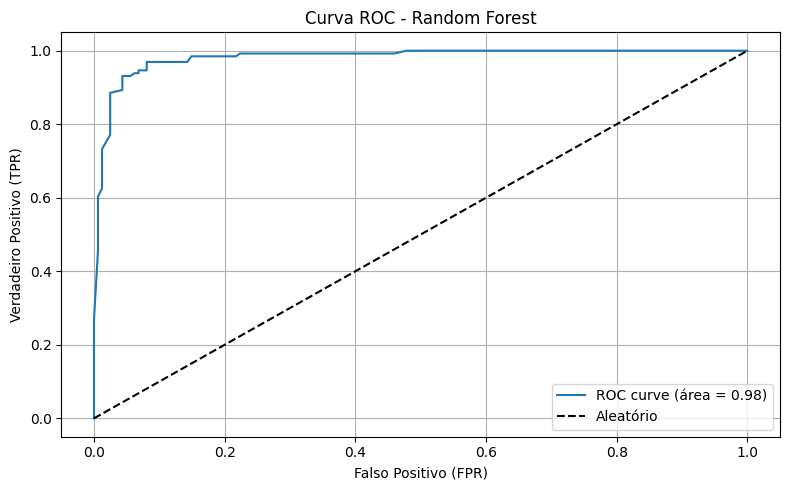

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC curve (área = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Aleatório")
plt.xlabel("Falso Positivo (FPR)")
plt.ylabel("Verdadeiro Positivo (TPR)")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<ul>
    <li><strong>Acurácia (93%):</strong> Representa a proporção total de previsões corretas, indicando que o modelo classifica corretamente a maioria dos casos.</li>
    <li><strong>Precisão (92%):</strong> Mede a taxa de acertos entre as previsões positivas, ou seja, dos imóveis que o modelo previu como pertencentes a uma determinada classe, 92% realmente pertencem a ela.</li>
    <li><strong>Recall (94%):</strong> Indica a capacidade do modelo em identificar corretamente os casos positivos reais, sendo eficaz na detecção dos imóveis da classe de interesse.</li>
    <li><strong>F1-Score (93%):</strong> É uma média harmônica entre precisão e recall, representando o equilíbrio do modelo entre os falsos positivos e falsos negativos.</li>
    <li><strong>ROC AUC (98%):</strong> Área sob a curva ROC, que avalia a separação entre as classes. Um valor de 0.98 demonstra um excelente desempenho, muito próximo do ideal (1.0), indicando que o modelo distingue as classes de forma altamente eficiente.</li>
</ul>

<h3>Curva ROC:</h3>

<p>No gráfico, observamos a <strong>Curva ROC</strong> (Receiver Operating Characteristic), que ilustra a relação entre a taxa de verdadeiros positivos (TPR) e a taxa de falsos positivos (FPR) em diferentes limiares de decisão.</p>

<p>A linha azul representa o desempenho do modelo, enquanto a linha preta tracejada indica o comportamento de um classificador aleatório (linha de base). A curva azul posiciona-se significativamente acima da linha de base, reforçando o excelente poder discriminativo do modelo.</p>

<p>O valor da <strong>área sob a curva (AUC)</strong> de 0.98 evidencia que, em <strong>98% das vezes</strong>, o modelo é capaz de diferenciar corretamente as classes positivas e negativas, demonstrando alta eficácia, robustez e confiabilidade na tarefa de classificação.</p>